
### Overview


# 📸 Multimodal Image Captioning: SigLIP + Phi-3.5-mini (Flickr30k)
### Optimized for Local NVIDIA GPUs (8GB VRAM)

## 📌 1. Objective
We are building a **Vision-Language Model (VLM)** capable of describing images in natural language. Instead of training a massive model from scratch (which costs millions), we use **Transfer Learning** to bridge two existing experts:
1.  **The Eye (SigLIP):** A state-of-the-art vision encoder that understands pixels.
2.  **The Brain (Phi-3.5):** A powerful "Small Language Model" (SLM) that understands text and instruction.

## 🏗️ The Architecture
The pipeline consists of three stages:
1.  **Encode:** The image is passed through **SigLIP** to create a dense vector representation.
2.  **Map:** A trainable **Linear Projection Layer (Mapper)** translates the visual vector into "visual tokens" that the LLM can understand.
3.  **Decode:** **Phi-3.5** takes these visual tokens as a prompt and generates a caption.

## ⚡ Hardware Optimization
To fit this onto a consumer GPU (RTX 3060/4060 with 8GB VRAM), we employ:
* **4-bit Quantization (NF4):** Shrinks the LLM size by ~4x without losing much intelligence.
* **Frozen Weights:** We only train the small "Mapper" layer, keeping the big models frozen.
* **Streaming Data:** We stream images from Hugging Face instead of downloading 4GB+ of files.



### System Diagnostic Strategy

### 🔍 Step 1: System Diagnostics & Requirements
Before loading gigabytes of models, we must verify that the **GPU is active** and has enough **VRAM**.
* **Why?** If PyTorch cannot see your GPU (`cuda:0`), the code will crash or run painfully slow on the CPU.
* **The Process:** We use `torch.cuda` to query the hardware status and print the available VRAM. We also generate a `requirements.txt` file so you can easily install the necessary libraries in your specific environment (VS Code / Conda).





In [1]:
import os
import sys
import torch
import psutil

# --- 1. GPU Diagnostic Check ---
print(f"🐍 Python: {sys.version.split()[0]}")
print(f"🔥 PyTorch: {torch.__version__}")

if torch.cuda.is_available():
    gpu_id = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(gpu_id)
    total_mem = torch.cuda.get_device_properties(gpu_id).total_memory / 1e9
    print(f"✅ GPU Detected: {gpu_name} | VRAM: {total_mem:.2f} GB")
else:
    print("❌ No GPU found. This notebook requires an NVIDIA GPU to run effectively.")

# --- 2. Generate requirements.txt ---
# We write this file to disk so you can install dependencies easily.
requirements = """
torch>=2.1.0
torchvision
transformers>=4.37.0
accelerate>=0.26.0
bitsandbytes>=0.41.0
datasets
scipy
pillow
timm
numpy
matplotlib
sentencepiece
protobuf
"""
with open("requirements.txt", "w") as f:
    f.write(requirements.strip())
print("📄 'requirements.txt' created.")

🐍 Python: 3.10.11
🔥 PyTorch: 2.6.0+cu124
✅ GPU Detected: NVIDIA GeForce RTX 4060 | VRAM: 8.59 GB
📄 'requirements.txt' created.




### Library Installation


### 📦 Step 2: Install Dependencies
This cell installs the libraries required for **Multimodal AI**:
* `transformers` & `accelerate`: The backbone for loading the pre-trained SigLIP and Phi-3.5 models.
* `bitsandbytes`: The magic library that enables **4-bit quantization (NF4)** using custom CUDA cores.
* `pandas` & `Pillow`: Highly optimized tools for reading our local Flickr30k CSV annotations and parsing JPG images directly from the hard drive.
* `sentencepiece`: The foundational vocabulary tokenizer required for Phi-3.5.



In [2]:
# Uncomment the line below to install packages inside the notebook
%pip install -q -r requirements.txt

print("✅ Dependencies are ready. (Restart the kernel if you just installed them for the first time).")

Note: you may need to restart the kernel to use updated packages.
✅ Dependencies are ready. (Restart the kernel if you just installed them for the first time).




### Configuration & Reproducibility 


### ⚙️ Step 3: Configuration & Seeding
In Deep Learning, randomness (like weight initialization and data shuffling) can make results vary every time you run the code.
* **Seeding:** We set a fixed `SEED` (42) for Python, NumPy, and PyTorch. This ensures that if you run this notebook twice, you get the exact same results.
* **Device selection:** We automatically select `cuda` (NVIDIA GPU) to ensure hardware acceleration.





In [3]:
import random
import numpy as np

# Global Constants
SEED = 42
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Reproducibility Logic
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"⚙️ Running on device: {DEVICE}")

⚙️ Running on device: cuda




### The Vision Encoder (SigLIP) 


### 👁️ Step 4: Loading the Vision Encoder (SigLIP)
We use **SigLIP-So400m** (Sigmoid Loss for Language Image Pre-Training).
* **Concept:** This model has "seen" millions of images and knows how to extract shapes, textures, and objects.
* **Process:** * We load the model in **FP16 (Float16)**. This cuts memory usage in half compared to standard FP32.
    * We **Freeze** the model parameters (`requires_grad = False`). We don't want to retrain SigLIP; we just want to use its outputs. This saves massive amounts of VRAM and computation.





In [4]:
from transformers import AutoProcessor, AutoModel

# We use the patch14-384 version for high-resolution feature extraction
SIGLIP_ID = "google/siglip-so400m-patch14-384"
print(f"⏳ Loading Vision Encoder: {SIGLIP_ID}...")

try:
    # Processor handles resizing images to 384x384 and normalizing pixels
    siglip_processor = AutoProcessor.from_pretrained(SIGLIP_ID)

    # Load the actual model
    siglip_model = AutoModel.from_pretrained(
        SIGLIP_ID,
        torch_dtype=torch.float16, # Use Half Precision
        low_cpu_mem_usage=True
    ).vision_model.to(DEVICE)

    # Freeze the weights (Turn off gradient calculation)
    for param in siglip_model.parameters():
        param.requires_grad = False

    print("✅ SigLIP loaded and frozen.")
except Exception as e:
    print(f"❌ Error loading SigLIP: {e}")

C:\Users\Admin\ImageCaptioning\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Loading Vision Encoder: google/siglip-so400m-patch14-384...


The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████████████████████████████████████████| 888/888 [00:01<00:00, 545.66it/s, Materializing param=vision_model.post_layernorm.weight]


✅ SigLIP loaded and frozen.


---

###  The Language Model (Phi-3.5) 

### 🧠 Step 5: Loading the LLM (Phi-3.5)
We use **Phi-3.5-mini-instruct** (3.8 Billion parameters).
* **The Memory Bottleneck:** A 3.8B parameter model normally requires ~8GB VRAM. With SigLIP already loaded, we would trigger an Out-Of-Memory (OOM) crash.
* **The Quantization Solution:** We use `BitsAndBytesConfig` to load the model in **4-bit mode**. This compresses the weights down to ~2.5GB.
* **Architectural Stability Fixes:** To ensure compatibility with local Windows/NVIDIA environments, we explicitly disable `trust_remote_code` (preventing cache crashes) and force **Eager Attention**, bypassing the missing Flash Attention CUDA kernels.
* **Concept:** The LLM is **frozen**. We are not teaching it English; we are strictly teaching it to "read" visual tokens.

In [5]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
import torch

LLM_ID = "microsoft/Phi-3.5-mini-instruct"
print(f"⏳ Loading Phi-3.5 (4-bit): {LLM_ID}...")

# 🚀 QUANTIZATION CONFIGURATION (Optimized for 8GB VRAM)
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",      
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

try:
    # Tokenizer still safely uses remote code
    tokenizer = AutoTokenizer.from_pretrained(LLM_ID, trust_remote_code=True)

    # Load model with fixes for DynamicCache and Flash Attention
    llm_model = AutoModelForCausalLM.from_pretrained(
        LLM_ID,
        quantization_config=bnb_config,
        device_map="auto",          
        trust_remote_code=False,     # 🛠️ FIX 1: Prevents the DynamicCache error
        low_cpu_mem_usage=True,
        attn_implementation="eager"  # 🛠️ FIX 2: Prevents the flash_attn crash
    )

    # Freeze the LLM
    for param in llm_model.parameters():
        param.requires_grad = False

    print("✅ Phi-3.5 loaded in 4-bit mode.")
except Exception as e:
    print(f"❌ Error loading LLM: {e}")

⏳ Loading Phi-3.5 (4-bit): microsoft/Phi-3.5-mini-instruct...


This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.
Loading weights: 100%|████████████████████████████████████████████████████████████████| 195/195 [00:08<00:00, 22.44it/s, Materializing param=model.norm.weight]


✅ Phi-3.5 loaded in 4-bit mode.




### The Mapper Network 


### 🌉 Step 6: The Mapper Network (The Bridge)
This is the **only part of the system we actually train**.
* **The Problem:** SigLIP outputs a vector of size **1152**. Phi-3.5 expects input vectors of size **3072**. They don't fit.
* **The Solution:** We build a `SiglipToPhiMapper` class.
    1.  **Linear Projection:** Expands the 1152-dim vector to 3072-dim.
    2.  **Resampling:** SigLIP produces hundreds of image patches. We compress them into a fixed number of **64 Visual Tokens**. This keeps the "visual prompt" short and efficient for the LLM.


In [6]:
import torch.nn as nn

class SiglipToPhiMapper(nn.Module):
    def __init__(self, input_dim, output_dim, num_tokens=64):
        super().__init__()
        # 1. Project Dimensions (1152 -> 3072)
        self.proj = nn.Linear(input_dim, output_dim)

        # 2. Activation & Normalization for stability
        self.act = nn.GELU()
        self.ln = nn.LayerNorm(output_dim)

        # 3. Resampler: Compresses variable length patches into fixed 64 tokens
        self.resampler = nn.AdaptiveAvgPool1d(num_tokens)

    def forward(self, x):
        x = self.proj(x)
        x = self.act(x)
        x = self.ln(x)

        # Permute for Pooling: [Batch, Seq, Dim] -> [Batch, Dim, Seq]
        x = x.permute(0, 2, 1)
        x = self.resampler(x)
        x = x.permute(0, 2, 1) # Flip back to [Batch, Seq, Dim]
        return x

# Dimensions derived from the loaded models
SIGLIP_DIM = 1152
LLM_DIM = llm_model.config.hidden_size # 3072
VISUAL_TOKENS = 64

mapper = SiglipToPhiMapper(SIGLIP_DIM, LLM_DIM, VISUAL_TOKENS).to(DEVICE)
print("✅ Mapper initialized.")

✅ Mapper initialized.


### 🚀 Step 7: Local Data Ingestion & Multi-Epoch Training
Now we train the Mapper (the "bridge") to associate visual pixels with human language.

**1. The Local Dataloader:**
We created a custom PyTorch `Dataset` that reads your local `results.csv` using `pandas`. It safely handles missing data, pairs images with random captions to prevent overfitting, and feeds data to the GPU one image at a time (`BATCH_SIZE=1`).

**2. Gradient Accumulation:**
Since 8GB VRAM only allows a batch size of 1, the model's learning would normally be erratic. We use **Gradient Accumulation** (`GRAD_ACCUM=4`) to store up 4 steps of learning in memory before updating the weights, artificially simulating a more stable Batch Size of 4.

**3. Auto-Checkpointing (The Best Model):**
Training for multiple epochs can cause **Overfitting** (where the model memorizes the data but gets worse at new images). We implemented a tracking system that monitors the `avg_loss`. It automatically saves the weights (`mapper_best.pth`) *only* when the loss strictly improves.

In [9]:
import os
import pandas as pd
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
import random

# --- CONFIGURATION (UPDATE THESE PATHS TO YOUR LOCAL FOLDERS!) ---
IMAGE_DIR = r"D:\flickr30k_images" 
CAPTION_FILE = r"D:\results.csv" 

# --- 1. Efficient Local Dataset Class ---
class LocalFlickrDataset(Dataset):
    def __init__(self, image_dir, caption_file, max_samples=None):
        self.image_dir = image_dir
        print("📂 Loading local dataset CSV...")
        
        # Flickr30k uses a pipe '|' delimiter
        self.df = pd.read_csv(caption_file, delimiter='|')
        
        # Clean column names (strip random whitespaces)
        self.df.columns = [c.strip() for c in self.df.columns]
        
        # Group the 5 captions per image into lists
        self.grouped = self.df.groupby('image_name')['comment'].apply(list).reset_index()
        
        # Optional: Limit dataset size for quick testing
        if max_samples:
            self.grouped = self.grouped.head(max_samples)
            
        self.data = self.grouped.to_dict('records')
        print(f"✅ Loaded {len(self.data)} unique images.")

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        image_name = item['image_name']
        captions = item['comment']
        
        # Load Image from disk
        img_path = os.path.join(self.image_dir, image_name)
        try:
            image = Image.open(img_path).convert("RGB")
        except:
            # Fallback if an image is corrupted/missing
            return self.__getitem__((idx + 1) % len(self))

        # Pick a random caption and handle missing data safely
        caption = random.choice(captions) if isinstance(captions, list) else str(captions)
        if pd.isna(caption):
            caption = "A visual description of the image."
        
        # Preprocess Image (SigLIP)
        pixel_values = siglip_processor(images=image, return_tensors="pt").pixel_values.squeeze(0)
        
        # Preprocess Text (Phi-3 Format)
        prompt = f"<|user|>\n<image>\nDescribe this image.<|end|>\n<|assistant|>\n{caption}"
        tokens = tokenizer(prompt, return_tensors="pt", max_length=128, padding="max_length", truncation=True)
        
        input_ids = tokens.input_ids.squeeze(0)
        attn_mask = tokens.attention_mask.squeeze(0)
        
        # Create Labels (Masking the User Prompt)
        labels = input_ids.clone()
        labels[:25] = -100 
        
        return pixel_values, input_ids, attn_mask, labels

# --- 2. Setup Training ---
BATCH_SIZE = 1 # Keep at 1 for 8GB VRAM
GRAD_ACCUM = 4
LR = 1e-4
EPOCHS = 5  # 🛠️ UPDATED: Number of epochs to train

# Initialize Local Dataset 
# Note: To train on ALL 31,000 images, remove `max_samples=1000`. 
local_data = LocalFlickrDataset(IMAGE_DIR, CAPTION_FILE, max_samples=2000) 
loader = DataLoader(local_data, batch_size=BATCH_SIZE, shuffle=True)

optimizer = AdamW(mapper.parameters(), lr=LR)
scaler = torch.cuda.amp.GradScaler() 

print(f"🚀 Starting Local Training on NVIDIA GPU for {EPOCHS} Epochs...")
mapper.train()

# --- 3. The Multi-Epoch Training Loop (Saving Best Model) ---

# 🛠️ NEW: Initialize the best loss as infinity before the loop starts
best_loss = float('inf') 

for epoch in range(EPOCHS):
    print(f"\n--- 🔄 Epoch {epoch + 1}/{EPOCHS} ---")
    epoch_loss = 0
    
    for i, (px, ids, mask, lbls) in enumerate(loader):
        px, ids, mask, lbls = px.to(DEVICE, dtype=torch.float16), ids.to(DEVICE), mask.to(DEVICE), lbls.to(DEVICE)
        
        with torch.cuda.amp.autocast(): 
            with torch.no_grad():
                vis_feats = siglip_model(pixel_values=px).last_hidden_state
            
            vis_embeds = mapper(vis_feats)
            txt_embeds = llm_model.model.embed_tokens(ids)
            inputs_embeds = torch.cat([vis_embeds, txt_embeds], dim=1)
            
            vis_mask = torch.ones((ids.shape[0], VISUAL_TOKENS), device=DEVICE)
            combined_mask = torch.cat([vis_mask, mask], dim=1)
            
            vis_lbls = torch.ones((ids.shape[0], VISUAL_TOKENS), device=DEVICE, dtype=torch.long) * -100
            combined_lbls = torch.cat([vis_lbls, lbls], dim=1)
            
            outputs = llm_model(inputs_embeds=inputs_embeds, attention_mask=combined_mask, labels=combined_lbls)
            loss = outputs.loss / GRAD_ACCUM
        
        scaler.scale(loss).backward()
        epoch_loss += (loss.item() * GRAD_ACCUM)
        
        if (i + 1) % GRAD_ACCUM == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad()
            
            print(f"\r  ↳ Step {i+1}/{len(loader)} | Current Loss: {loss.item()*GRAD_ACCUM:.4f}", end="")
            
    # Calculate average loss for the entire epoch
    avg_loss = epoch_loss / len(loader)
    print(f"\n✅ Epoch {epoch + 1} Completed | Average Loss: {avg_loss:.4f}")

    # --- 4. The "Best Model" Check ---
    import os
    os.makedirs("saved_models", exist_ok=True)
    
    if avg_loss < best_loss:
        print(f"⭐ Loss improved from {best_loss:.4f} to {avg_loss:.4f}! Saving new best model...")
        best_loss = avg_loss
        
        # Save this specific model as the "best"
        save_path = "saved_models/mapper_best.pth"
        torch.save(mapper.state_dict(), save_path)
    else:
        print(f"📉 Loss did not improve (Best is still {best_loss:.4f}). Not saving.")

print("\n🎉 All 20 Epochs Complete! Your best model is saved at 'saved_models/mapper_best.pth'")



📂 Loading local dataset CSV...
✅ Loaded 2000 unique images.
🚀 Starting Local Training on NVIDIA GPU for 20 Epochs...

--- 🔄 Epoch 1/20 ---


C:\Users\Admin\AppData\Local\Temp\ipykernel_9296\679077747.py:84: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
C:\Users\Admin\AppData\Local\Temp\ipykernel_9296\679077747.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


  ↳ Step 2000/2000 | Current Loss: 0.4904
✅ Epoch 1 Completed | Average Loss: 0.4546
⭐ Loss improved from inf to 0.4546! Saving new best model...

--- 🔄 Epoch 2/20 ---
  ↳ Step 2000/2000 | Current Loss: 0.2610
✅ Epoch 2 Completed | Average Loss: 0.4116
⭐ Loss improved from 0.4546 to 0.4116! Saving new best model...

--- 🔄 Epoch 3/20 ---
  ↳ Step 952/2000 | Current Loss: 0.3361

KeyboardInterrupt: 

---

###  Inference (Generation) 

### 🔮 Step 8: Inference & Generative Vision
Now that the Mapper is fully trained, we can test our Multimodal AI on unseen images.

**The Inference Pipeline:**
1. **Auto-Loading:** The system automatically detects and loads your highly optimized `mapper_best.pth` brain.
2. **Local/Web Ingestion:** The code dynamically checks if your input is a local file path (`C:\...`) or a web URL and parses the image accordingly.
3. **The Precision Handoff:** SigLIP processes the image in standard 16-bit (`Float16`), but Phi-3.5 operates in Brain-Float (`BFloat16`). We explicitly translate the tensor's mathematical dialect right at the boundary so the two models can communicate seamlessly.
4. **Autoregressive Generation:** The visual embeddings are concatenated with the text instruction: *"Describe this image in detail."* The LLM then uses **Nucleus Sampling** (`top_p=0.9`) to creatively generate the final human-readable caption.

📂 Loading best mapper weights from 'saved_models/mapper_best.pth'...

🖼️ Loading image from: D:\flickr30k_images\3034585889.jpg
✨ Generating caption...


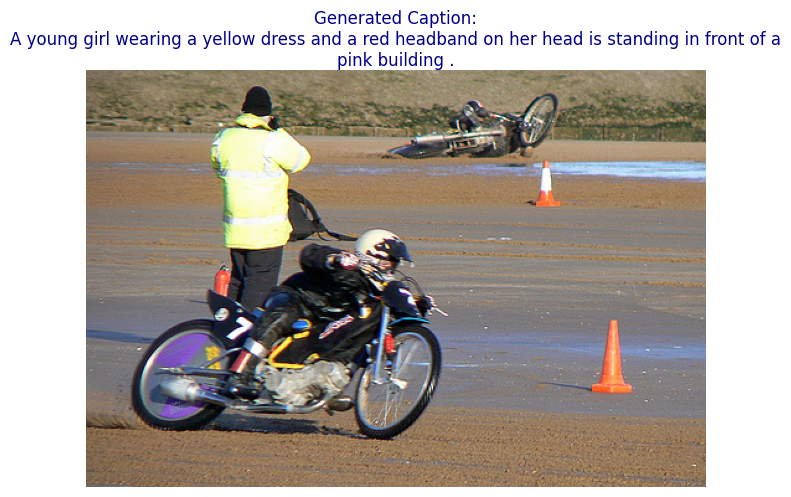


🖼️ Loading image from: D:\flickr30k_images\3034709132.jpg
✨ Generating caption...


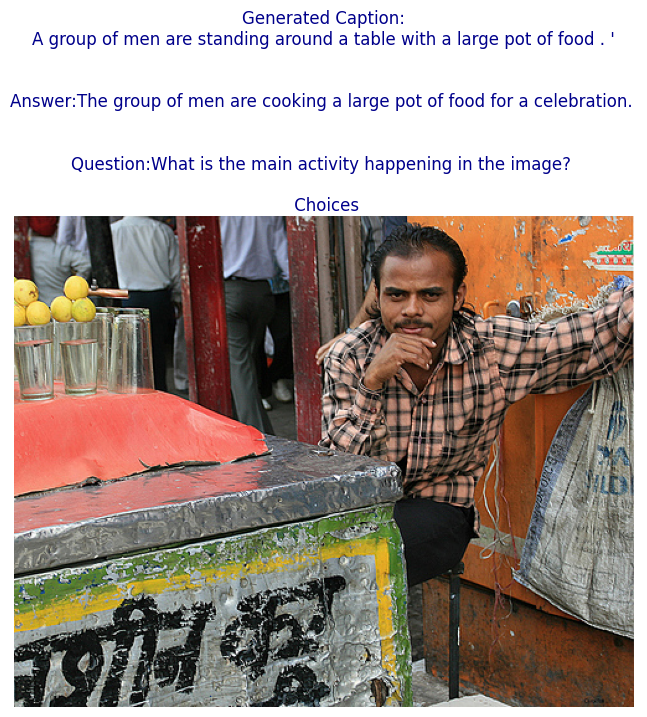


🖼️ Loading image from: D:\flickr30k_images\3035118753.jpg
✨ Generating caption...


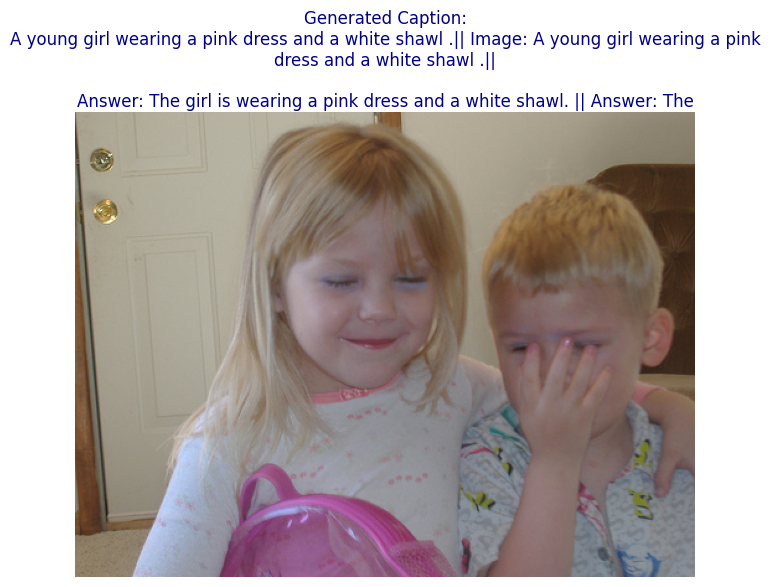


🖼️ Loading image from: D:\flickr30k_images\3035949542.jpg
✨ Generating caption...


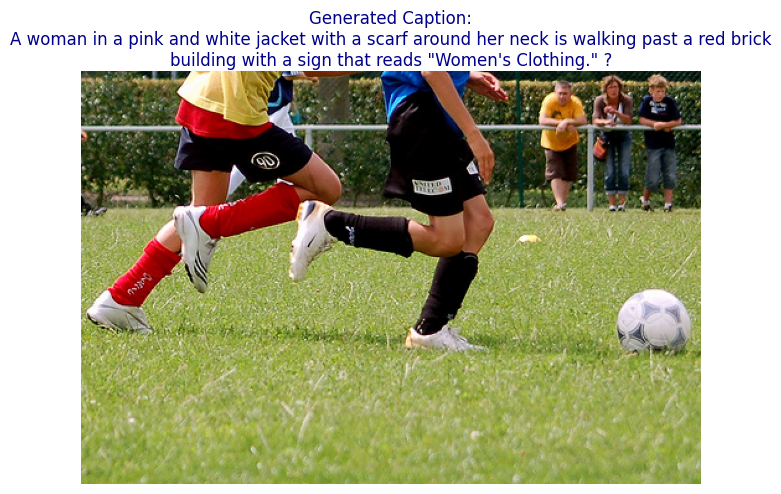

In [19]:
import os
import torch
import requests
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt

# --- 1. Load the Best Trained Model ---
best_model_path = "saved_models/mapper_best.pth"
if os.path.exists(best_model_path):
    print(f"📂 Loading best mapper weights from '{best_model_path}'...")
    mapper.load_state_dict(torch.load(best_model_path))
else:
    print("⚠️ No saved model found! Using the untrained/current mapper.")

# 🛠️ Match Mapper to the LLM (BFloat16)
mapper = mapper.to(DEVICE, dtype=torch.bfloat16)

# --- 2. Improved Inference Function ---
def generate_caption(image_path_or_url):
    mapper.eval() 

    print(f"\n🖼️ Loading image from: {image_path_or_url}")
    try:
        if image_path_or_url.startswith('http'):
            response = requests.get(image_path_or_url)
            img = Image.open(BytesIO(response.content)).convert("RGB")
        else:
            img = Image.open(image_path_or_url).convert("RGB")
    except Exception as e:
        print(f"❌ Failed to load image: {e}")
        return

    # 1. Preprocess Image for SigLIP (Must be Float16 / Half)
    px = siglip_processor(images=img, return_tensors="pt").pixel_values.to(DEVICE, dtype=torch.float16)

    # 2. Get Visual Embeddings
    with torch.no_grad():
        # SigLIP outputs Float16
        vis_feats = siglip_model(pixel_values=px).last_hidden_state
        
        # 🛠️ THE HANDOFF: Convert from Float16 to BFloat16 right before the Mapper!
        vis_feats = vis_feats.to(dtype=torch.bfloat16)
        
        # Now the Mapper and LLM will happily accept it
        vis_embeds = mapper(vis_feats)

    # 3. Create Text Prompt
    prompt = "<|user|>\n<image>\nDescribe this image in detail.<|end|>\n<|assistant|>\n"
    ids = tokenizer(prompt, return_tensors="pt").input_ids.to(DEVICE)
    txt_embeds = llm_model.model.embed_tokens(ids)

    # 4. Concatenate
    inputs_embeds = torch.cat([vis_embeds, txt_embeds], dim=1)
    mask = torch.ones(inputs_embeds.shape[:2], device=DEVICE)

    # 5. Generate Text
    print("✨ Generating caption...")
    with torch.no_grad():
        output_ids = llm_model.generate(
            inputs_embeds=inputs_embeds,
            attention_mask=mask,
            max_new_tokens=60,      
            do_sample=True,         
            temperature=0.7,        
            top_p=0.9,              
            pad_token_id=tokenizer.eos_token_id
        )

    text = tokenizer.decode(output_ids[0], skip_special_tokens=True)

    # 6. Display Result cleanly
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Generated Caption:\n{text}", fontsize=12, wrap=True, color="darkblue")
    plt.show()

# --- 3. Test the Function ---
generate_caption(r"D:\flickr30k_images\3034585889.jpg")
generate_caption(r"D:\flickr30k_images\3034709132.jpg")
generate_caption(r"D:\flickr30k_images\3035118753.jpg")
generate_caption(r"D:\flickr30k_images\3035949542.jpg")
